# BUS-BRA — Exploratory Data Analysis

Research prototype — not for diagnostic use.

Uses `src/data.py` (`build_master_df`) as the single source of truth for
image paths, labels, and the official patient-level folds.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data import build_master_df

# validated categorical palette (dataviz reference, light mode)
C_BENIGN, C_MALIGNANT, C_RED = "#2a78d6", "#eb6834", "#e34948"
SEQ_BLUES = ["#c9def5", "#8fbceb", "#5599e0", "#2a78d6"]  # light -> dark, one hue
INK, MUTED = "#1a1a19", "#6f6e66"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

df = build_master_df(ROOT / "data" / "raw" / "busbra")
print(f"{len(df)} images, {df['patient_id'].nunique()} patients")
df.head(3)

1875 images, 1064 patients


,image_path,mask_path,patient_id,label,birads,fold
0,/Users/thomaswang/projects/breast-us-cad/data/...,/Users/thomaswang/projects/breast-us-cad/data/...,1,1,4,3
1,/Users/thomaswang/projects/breast-us-cad/data/...,/Users/thomaswang/projects/breast-us-cad/data/...,1,1,4,3
2,/Users/thomaswang/projects/breast-us-cad/data/...,/Users/thomaswang/projects/breast-us-cad/data/...,2,0,4,5


## 1. Class balance and BI-RADS — image level vs patient level

Patient-level aggregation: a patient counts as **malignant if any image is
malignant**, and takes their **maximum BI-RADS** (most severe assessment).

patients with mixed benign/malignant labels: 0


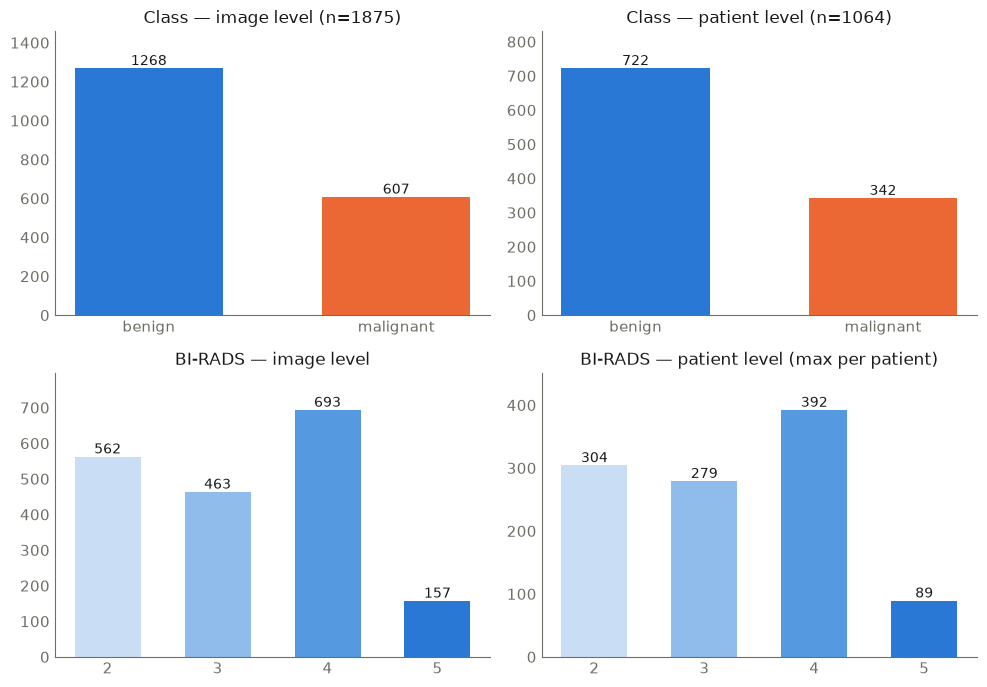

In [2]:
mixed = df.groupby("patient_id")["label"].nunique().gt(1).sum()
print(f"patients with mixed benign/malignant labels: {mixed}")

pat = df.groupby("patient_id").agg(label=("label", "max"), birads=("birads", "max"))

def barh_counts(ax, counts, colors, title):
    bars = ax.bar(counts.index.astype(str), counts.values, color=colors, width=0.6)
    for b in bars:
        ax.annotate(f"{int(b.get_height())}", (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", fontsize=10, color=INK)
    ax.set_title(title, color=INK, fontsize=12)
    ax.set_ylim(0, counts.max() * 1.15)
    ax.tick_params(length=0)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

cls_img = df["label"].map({0: "benign", 1: "malignant"}).value_counts()[["benign", "malignant"]]
cls_pat = pat["label"].map({0: "benign", 1: "malignant"}).value_counts()[["benign", "malignant"]]
barh_counts(axes[0, 0], cls_img, [C_BENIGN, C_MALIGNANT], "Class — image level (n=1875)")
barh_counts(axes[0, 1], cls_pat, [C_BENIGN, C_MALIGNANT], f"Class — patient level (n={len(pat)})")

bi_img = df["birads"].value_counts().sort_index()
bi_pat = pat["birads"].value_counts().sort_index()
barh_counts(axes[1, 0], bi_img, SEQ_BLUES, "BI-RADS — image level")
barh_counts(axes[1, 1], bi_pat, SEQ_BLUES, "BI-RADS — patient level (max per patient)")

fig.tight_layout()
plt.show()

## 2. Image dimensions

     Width  Height
min  240.0   268.0
50%  286.0   383.0
max  579.0   478.0


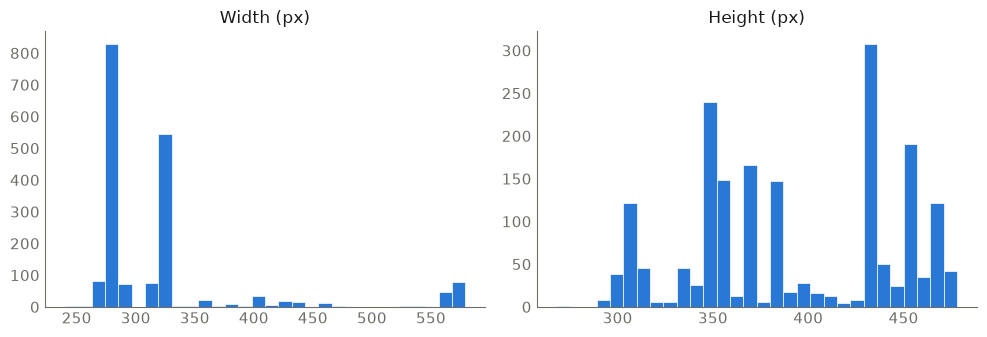

In [3]:
meta = pd.read_csv(ROOT / "data" / "raw" / "busbra" / "bus_data.csv")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, col in zip(axes, ["Width", "Height"]):
    ax.hist(meta[col], bins=30, color=C_BENIGN, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{col} (px)", color=INK, fontsize=12)
    ax.tick_params(length=0)
print(meta[["Width", "Height"]].describe().loc[["min", "50%", "max"]].round(0))
fig.tight_layout()
plt.show()

## 3. Sample images with segmentation masks (semi-transparent red overlay)

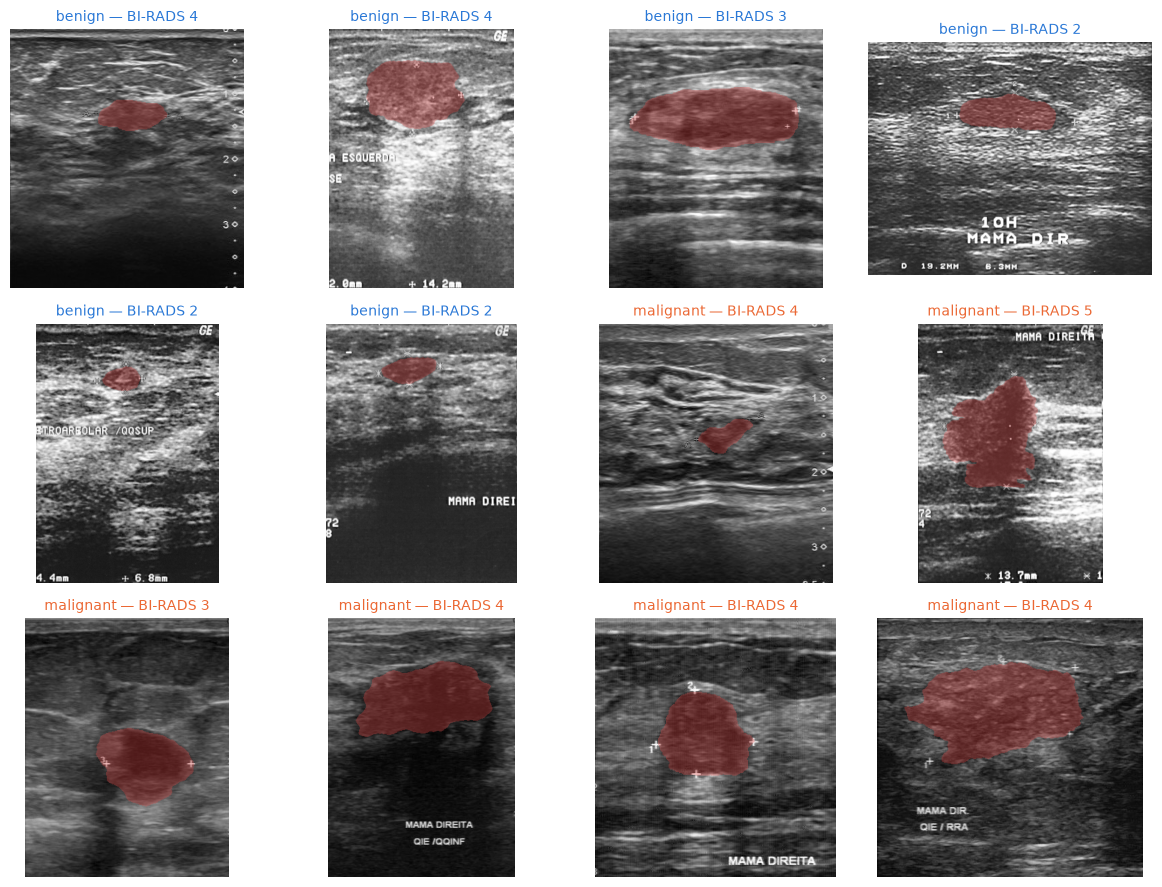

In [4]:
rng = np.random.default_rng(42)
sample = pd.concat([
    df[df["label"] == 0].sample(6, random_state=42),
    df[df["label"] == 1].sample(6, random_state=42),
]).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = cv2.imread(str(ROOT / row["image_path"]), cv2.IMREAD_GRAYSCALE)
    msk = cv2.imread(str(ROOT / row["mask_path"]), cv2.IMREAD_GRAYSCALE)
    overlay = np.zeros((*msk.shape, 4))
    overlay[msk > 0] = [0.89, 0.29, 0.28, 0.35]  # C_RED, alpha 0.35
    ax.imshow(img, cmap="gray")
    ax.imshow(overlay)
    name = "malignant" if row["label"] == 1 else "benign"
    ax.set_title(f"{name} — BI-RADS {row['birads']}", fontsize=10,
                 color=C_MALIGNANT if row["label"] == 1 else C_BENIGN)
    ax.axis("off")
fig.tight_layout()
plt.show()

## 4. Fold integrity — patient-level splits (golden rule #1)

Every patient must appear in exactly one official fold.

In [5]:
folds_per_patient = df.groupby("patient_id")["fold"].nunique()
leaky = folds_per_patient[folds_per_patient > 1]
assert leaky.empty, f"{len(leaky)} patient(s) span multiple folds: {leaky.index.tolist()[:10]}"
print(f"OK — all {len(folds_per_patient)} patients appear in exactly one fold")
df.groupby("fold").agg(images=("image_path", "count"),
                       patients=("patient_id", "nunique"),
                       malignant_frac=("label", "mean")).round(3)

OK — all 1064 patients appear in exactly one fold


,images,patients,malignant_frac
fold,,,
1,376,212,0.324
2,385,213,0.325
3,366,213,0.328
4,365,214,0.326
5,383,212,0.316
